Title: CMIP6_Data_test.ipynb

Purpose: Compare the different CMIP ESMs/Datasets

Author: Onno Nennecke on 19.04.2025 Modified: 02.05.2025

Input data: 

    - This file lies here: 

Output data:

    - This file lies here: 

### Load libraries and functions

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os
import glob
import time
import pandas as pd

# Importing functions
import Functions.wind_model_func as wind_model_func
import Functions.solar_model_func as solar_model_func
import Functions.demand as demand_func
import Functions.grid_func as grid_func
import Functions.config as config

/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/esmpy/interface/loadESMF.py:94: VersionWarning: ESMF installation version 8.8.0, ESMPy version 8.8.0b0
  warnings.warn("ESMF installation version {}, ESMPy version {}".format(


### Load datasets

In [2]:
# Load installed capacity data
grid_offshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_ic.nc')
grid_offshore = grid_offshore['wind_off_cap']
grid_onshore = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_ic.nc')
grid_onshore = grid_onshore['wind_on_cap']
grid_solar = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/solar_ic.nc')
grid_solar = grid_solar['solar_cap']

In [3]:
# Load wind height data
grid_onsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_onshore_height_weighted.nc')
grid_offsh_hub_height = xr.open_dataset('/climca/people/onennecke/Wind_Solar_MaStR/processed_data/wind_offshore_height_weighted.nc')

hub_height_on = grid_onsh_hub_height['wind_on_hub_height']
hub_height_off = grid_offsh_hub_height['wind_off_hub_height']

In [4]:
# Load regridded population weights data
pop_regr_CIESIN_weights = xr.open_dataset('/climca/people/onennecke/population_data/population_regrid_weights.nc')

# Load fit values from vdW Paper
demand_fit_values = xr.open_dataset('/climca/people/onennecke/population_data/demand_fit_values_week.nc')

### Define used models

In [5]:
# Load climate data

MIP = 'ScenarioMIP' # CMIP
Institution = '*'
# ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'CESM2-WACCM', 'CNRM-CM6-1', 'CNRM-CM6-1-HR', 'CNRM-ESM2-1', 'EC-Earth3', 'EC-Earth3-Veg', 'GFDL-CM4', 'GFDL-ESM4', 'HadGEM3-GC31-LL', 'HadGEM3-GC31-MM', 'MPI-ESM1-2-HR',
#            'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL']
ESMs = ['ACCESS-CM2', 'BCC-CSM2-MR', 'CESM2', 'EC-Earth3', 'GFDL-ESM4', 'MPI-ESM1-2-HR', 'MRI-ESM2-0', 'KACE-1-0-G', 'TaiESM1', 'UKESM1-0-LL'] # 'EC-Earth3-Veg'
# ESMs = ['ACCESS-CM2', 'EC-Earth3', 'MPI-ESM1-2-HR', 'MRI-ESM2-0'] # Datetime Format: datetime64
ESMs = ['BCC-CSM2-MR', 'CESM2', 'GFDL-ESM4', 'TaiESM1'] # Datetime Format: cftime.DatetimeNoLeap
# ESMs = ['KACE-1-0-G', 'UKESM1-0-LL'] # Datetime Format: cftime.Datetime360Day



# ESMs = ['EC-Earth3'] # 'EC-Earth3-Veg'

# ESMs = ['UKESM1-0-LL']
# ESMs = ['TaiEMS1', 'UKESM1-0LL']
scenario = 'ssp370'
# run = 'r1i1p1f1'
time_res = 'day'
variables = ['sfcWind', 'rsds', 'tas', 'tasmax'] # List of variables
grid_def = '*'
version = '*'


In [56]:
all_ts_outputs = []
for ESM in ESMs:
    print('ESM: ', ESM)
    path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/'
    matching_dirs = glob.glob(path)
    if len(matching_dirs) == 1:
        runs = os.listdir(matching_dirs[0])
    elif len(matching_dirs) >= 1:
        runs = os.listdir(matching_dirs[0]) + os.listdir(matching_dirs[1])
    else:
        print(f"Found {len(matching_dirs)} matching directories for {ESM} and {scenario}")
        break
    print('Runs: ', runs)
    for run in runs:
        ds_list = [] # List to hold individual datasets (one for each variable)

        run_time = time.time()
        print('Run: ', run)
        run_path = os.path.join(matching_dirs[0], run, 'day/') # Watch out for last model (then manually change to matching_dirs[1])
        
        # Check if all required folders (in `variables`) exist
        missing_folders = [var for var in variables if not os.path.isdir(os.path.join(run_path, var))]
        
        if missing_folders:
            print(f"Missing folders in {run_path}: {missing_folders}")
            continue
        
        missing_data = [
            var for var in variables 
            if not os.path.isdir(os.path.join(run_path, var)) or 
               not any(
                   os.path.isfile(f) 
                   for f in glob.glob(os.path.join(run_path, var, '*', '*', '*'))  # glob pattern to match files two levels down
               )
        ]
        
        if missing_data:
            print(f"Missing data in {run_path}: {missing_data}")
            continue
        
        for variable in variables:
            # print('Variable: ', variable)
            #path =f'/climca/data/CMIP6/CMIP/NCAR/{ESM}/{scenario}/{run}/day/{variable}/gn/v20190308/{variable}_day_{ESM}_{scenario}_{run}_gn_*'
            path = f'/climca/data/CMIP6/{MIP}/{Institution}/{ESM}/{scenario}/{run}/{time_res}/{variable}/{grid_def}/{version}/{variable}_{time_res}_{ESM}_{scenario}_{run}_*'
            # print('Open: ', path)
            
            # Filter out files with extensions after .nc
            files = [f for f in glob.glob(path) if f.endswith('.nc')]
            
            # Open with preprocessing (spatial filtering)
            if files:
                nc = xr.open_mfdataset(files, preprocess=grid_func.preprocess)
            else:
                print("No valid .nc files found!")
            # nc = xr.open_mfdataset(path, preprocess=grid_func.preprocess)
                
        #     # Keep only the desired variable, but retain Dataset structure
            nc = nc[[variable]]
            
            
            # Filter years
            nc = nc.sel(time=nc.time.dt.year.isin(range(2015, 2025)))

        #     # Append to list for later merging
            ds_list.append(nc)
            
            ds_list = [ds.drop_vars('height') if 'height' in ds.coords else ds for ds in ds_list]

        # # Combine all into a single dataset
        clim_ds = xr.merge(ds_list)
                
        if ds_list[2]['tas'].units == 'K':
            clim_ds['tas'] = clim_ds['tas'] - 273.15
        
        if ds_list[3]['tasmax'].units == 'K':
            clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15
            
        # Regrid the combined dataset
        combined_ds = grid_func.regrid(clim_ds)
        
        timeseries_ds = combined_ds.copy()
        timeseries_ds['sfcWind'] = combined_ds['sfcWind'].mean(dim=['lat', 'lon'])
        timeseries_ds['rsds'] = combined_ds['rsds'].mean(dim=['lat', 'lon'])
        timeseries_ds['tas'] = combined_ds['tas'].mean(dim=['lat', 'lon'])
        timeseries_ds['tasmax'] = combined_ds['tasmax'].mean(dim=['lat', 'lon'])
        
        ts_output = timeseries_ds.assign_coords(run = run, ESM = ESM, ESM_run = f'{ESM}_{run}')
        all_ts_outputs.append(ts_output)

for ds in all_ts_outputs:
    ds['time'] = all_ts_outputs[0]['time']
merged_ts = xr.concat(all_ts_outputs, dim='ESM_run')


ESM:  BCC-CSM2-MR
Runs:  ['r1i1p1f1']
Run:  r1i1p1f1
ESM:  CESM2
Runs:  ['r4i1p1f1', 'r10i1p1f1', 'r11i1p1f1']
Run:  r4i1p1f1


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tasmax' has multiple fill values {np.float32(1e+20), np.float6

Run:  r10i1p1f1


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tasmax' has multiple fill values {np.float32(1e+20), np.float6

Run:  r11i1p1f1


/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'sfcWind' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'rsds' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tas' has multiple fill values {np.float32(1e+20), np.float64(1e+20)} defined, decoding all values to NaN.
  var = coder.decode(var, name=name)
/home/onennecke/.conda/envs/env_ma_on/lib/python3.12/site-packages/xarray/conventions.py:200: SerializationWarning: variable 'tasmax' has multiple fill values {np.float32(1e+20), np.float6

ESM:  GFDL-ESM4
Runs:  ['r1i1p1f1']
Run:  r1i1p1f1
ESM:  TaiESM1
Runs:  ['r1i1p1f1']
Run:  r1i1p1f1


#### Some plots to check everything is alright

In [67]:
merged_ts['index'] = merged_ts['time'].dt.dayofyear
merged_ts

<xarray.Dataset> Size: 439kB
Dimensions:   (ESM_run: 6, time: 3650, lat: 10, lon: 12)
Coordinates:
  * time      (time) object 29kB 2015-01-01 12:00:00 ... 2024-12-31 12:00:00
  * lat       (lat) int64 80B 47 48 49 50 51 52 53 54 55 56
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 96B 5 6 7 8 9 10 11 12 13 14 15 16
    run       (ESM_run) <U9 216B 'r1i1p1f1' 'r4i1p1f1' ... 'r1i1p1f1' 'r1i1p1f1'
    ESM       (ESM_run) <U11 264B 'BCC-CSM2-MR' 'CESM2' ... 'TaiESM1'
  * ESM_run   (ESM_run) <U20 480B 'BCC-CSM2-MR_r1i1p1f1' ... 'TaiESM1_r1i1p1f1'
    index     (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
Data variables:
    sfcWind   (ESM_run, time) float32 88kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    rsds      (ESM_run, time) float32 88kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    tas       (ESM_run, time) float32 88kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    tasmax    (ESM_run, time) float32 88kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
Attributes:
    regrid_method:  bilinear

In [68]:
# Group data by ESMs and calculate mean temp, demand, wind, ...
all_dfs = []
for esm in np.unique(merged_ts['ESM'].values):
    filtered_dataset = merged_ts.where(merged_ts['ESM'] == esm, drop=True)
    mean_by_day = filtered_dataset.groupby('index').mean(dim=['time', 'ESM_run'])
    df = pd.DataFrame({
        'doy': mean_by_day['index'].values,
        'sfcWind': mean_by_day['sfcWind'].values,
        'rsds': mean_by_day['rsds'].values,
        'tas': mean_by_day['tas'].values,
        'tasmax': mean_by_day['tasmax'].values,
    })
    df['ESM'] = esm
    all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)



In [69]:
final_df

,doy,sfcWind,rsds,tas,tasmax,ESM
0,1,5.229932,21.458118,2.670018,4.718812,BCC-CSM2-MR
1,2,5.739282,17.542374,2.820007,4.393554,BCC-CSM2-MR
2,3,5.363036,19.526016,2.860857,4.506474,BCC-CSM2-MR
3,4,5.056165,17.597065,3.270438,4.804337,BCC-CSM2-MR
4,5,5.162913,21.801840,3.777637,5.451185,BCC-CSM2-MR
...,...,...,...,...,...,...
1455,361,4.644598,23.248419,4.990513,6.876257,TaiESM1
1456,362,4.550433,23.764008,5.391774,7.162973,TaiESM1
1457,363,4.474178,25.490662,4.914183,6.539036,TaiESM1
1458,364,4.213995,23.747150,4.819936,6.459754,TaiESM1


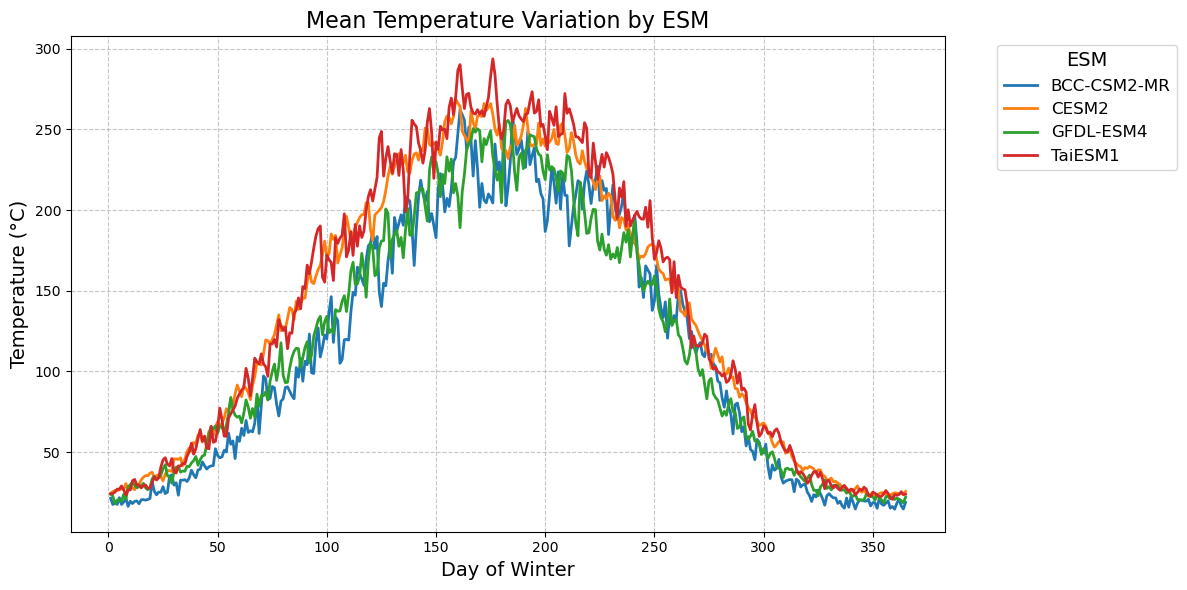

In [73]:
# Plot the data
plt.figure(figsize=(12, 6))
for esm, group in final_df.groupby('ESM'):
    plt.plot(group['doy'], group['rsds'], label=esm, linewidth=2)

# Add title and labels
plt.title('Mean Temperature Variation by ESM', fontsize=16)
plt.xlabel('Day of Winter', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=14)

# Customize legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title='ESM', title_fontsize=14)

# Add grid for better readability
plt.grid(visible=True, linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap
plt.tight_layout()

In [59]:
# Rename the existing 'index' coordinate to avoid conflicts
# if 'index' in merged_ts.coords:
# 	merged_ts = merged_ts.rename({'index': 'existing_index'})

# Add a new 'index' variable
merged_ts = merged_ts.assign_coords(index=np.arange(3650))
merged_ts

<xarray.Dataset> Size: 410kB
Dimensions:   (ESM_run: 6, time: 3650, lat: 10, lon: 12, index: 3650)
Coordinates:
  * time      (time) object 29kB 2015-01-01 12:00:00 ... 2024-12-31 12:00:00
  * lat       (lat) int64 80B 47 48 49 50 51 52 53 54 55 56
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * lon       (lon) int64 96B 5 6 7 8 9 10 11 12 13 14 15 16
    run       (ESM_run) <U9 216B 'r1i1p1f1' 'r4i1p1f1' ... 'r1i1p1f1' 'r1i1p1f1'
    ESM       (ESM_run) <U11 264B 'BCC-CSM2-MR' 'CESM2' ... 'TaiESM1'
  * ESM_run   (ESM_run) <U20 480B 'BCC-CSM2-MR_r1i1p1f1' ... 'TaiESM1_r1i1p1f1'
  * index     (index) int64 29kB 0 1 2 3 4 5 6 ... 3644 3645 3646 3647 3648 3649
Data variables:
    sfcWind   (ESM_run, time) float32 88kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    rsds      (ESM_run, time) float32 88kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    tas       (ESM_run, time) float32 88kB dask.array<chunksize=(1, 1), meta=np.ndarray>
    tasmax    (ESM_run, time) float32 88kB dask.array<chunksize=(1, 1), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

In [45]:
merged_ts.isel(ESM_run=0)['tas'].values

array([      nan, 3.7595527,       nan, ..., 7.141867 ,       nan,
       7.2442675], dtype=float32)

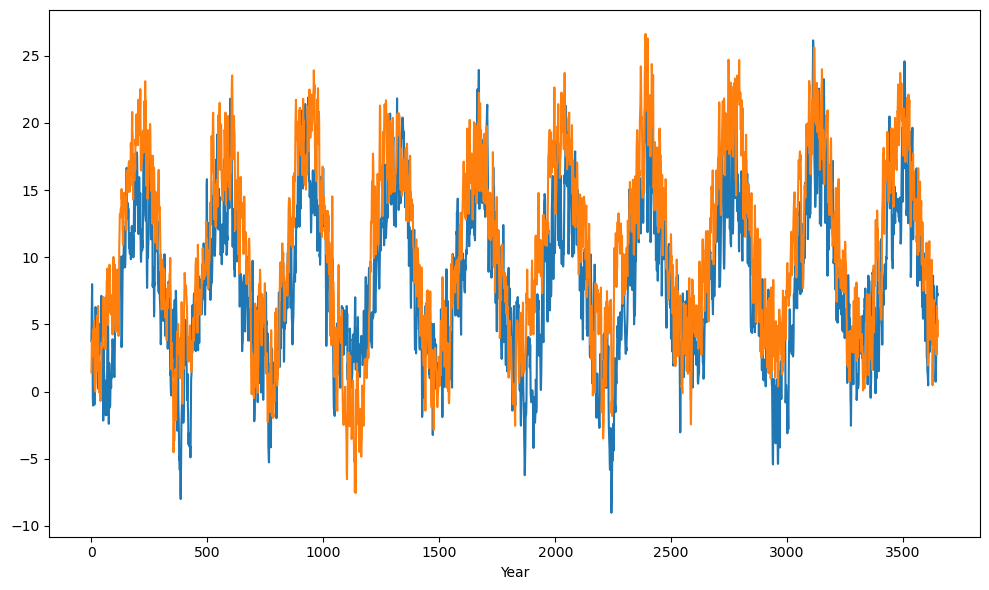

In [60]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

plt.figure(figsize=(10, 6))

# Convert time to pandas datetime for plotting
# years = merged_ts['time'].dt.year
for esm in np.unique(merged_ts['ESM_run'].values[0:2]):
    tas_values = merged_ts.sel(ESM_run=esm)['tas'].values
    plt.plot(merged_ts['index'], tas_values, label=esm)

plt.xlabel("Year")
# plt.ylabel(f"Annual mean {var}")
# plt.title(f"Annual mean {var} by ESM (2015–2024)")
# plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


In [8]:
np.unique(merged_ts['ESM'].values)

array(['BCC-CSM2-MR', 'CESM2', 'GFDL-ESM4', 'TaiESM1'], dtype='<U11')

In [9]:
merged_ts

<xarray.Dataset> Size: 84MB
Dimensions:   (ESM_run: 6, time: 7300, lat: 10, lon: 12)
Coordinates:
  * time      (time) object 58kB 2015-01-01 00:00:00 ... 2024-12-31 12:00:00
  * lat       (lat) int64 80B 47 48 49 50 51 52 53 54 55 56
  * lon       (lon) int64 96B 5 6 7 8 9 10 11 12 13 14 15 16
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    run       (ESM_run) <U9 216B 'r1i1p1f1' 'r4i1p1f1' ... 'r1i1p1f1' 'r1i1p1f1'
    ESM       (ESM_run) <U11 264B 'BCC-CSM2-MR' 'CESM2' ... 'TaiESM1'
  * ESM_run   (ESM_run) <U20 480B 'BCC-CSM2-MR_r1i1p1f1' ... 'TaiESM1_r1i1p1f1'
Data variables:
    sfcWind   (ESM_run, time, lat, lon) float32 21MB dask.array<chunksize=(1, 1, 10, 12), meta=np.ndarray>
    rsds      (ESM_run, time, lat, lon) float32 21MB dask.array<chunksize=(1, 1, 10, 12), meta=np.ndarray>
    tas       (ESM_run, time, lat, lon) float32 21MB dask.array<chunksize=(1, 1, 10, 12), meta=np.ndarray>
    tasmax    (ESM_run, time, lat, lon) float32 21MB dask.array<chunksize=(1, 1, 10, 12), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear

In [11]:
ds = merged_ts  # assuming you've already got it as merged_ts

# 2. Select the variable you want to plot
var = "tas"
da = ds[var]

# 3. Spatially average over lat and lon
da_spatial = da.mean(dim=["lat", "lon"])
# Now da_spatial is (ESM_run, time)

# 4. Compute the ensemble‐mean per ESM (i.e. average over runs of the same model)
#    ESM is a coordinate on the ESM_run dimension
# da_esm_mean = (
#     da_spatial
#     .groupby("ESM")           # groups the 71 runs by their ESM name
#     .mean(dim="ESM_run")      # averages the runs within each ESM
# )
# Now da_esm_mean has dims (ESM, time)

# 5. Collapse to annual means
# da_annual = (
#     da_esm_mean
#     .groupby("time.year")     # group by calendar year
#     .mean(dim="time")         # average all days within each year
# )
# Now da_annual has dims (ESM, year)

# 6. Convert to a pandas DataFrame for easy plotting
# df = da_annual.to_series().unstack("ESM")
# DataFrame indexed by year, columns are ESM names

In [13]:
da_spatial

<xarray.DataArray 'tas' (ESM_run: 6, time: 7300)> Size: 175kB
dask.array<mean_agg-aggregate, shape=(6, 7300), dtype=float32, chunksize=(1, 1), chunktype=numpy.ndarray>
Coordinates:
  * time      (time) object 58kB 2015-01-01 00:00:00 ... 2024-12-31 12:00:00
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    run       (ESM_run) <U9 216B 'r1i1p1f1' 'r4i1p1f1' ... 'r1i1p1f1' 'r1i1p1f1'
    ESM       (ESM_run) <U11 264B 'BCC-CSM2-MR' 'CESM2' ... 'TaiESM1'
  * ESM_run   (ESM_run) <U20 480B 'BCC-CSM2-MR_r1i1p1f1' ... 'TaiESM1_r1i1p1f1'

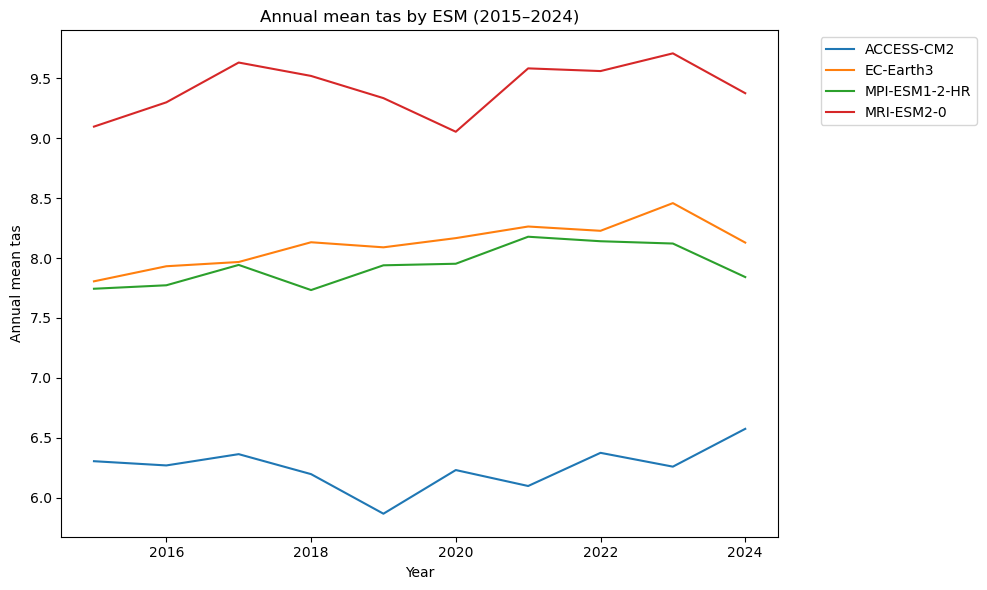

In [12]:
# 7. Plot
plt.figure(figsize=(10, 6))
for esm in df.columns:
    plt.plot(df.index, df[esm], label=esm)
plt.xlabel("Year")
plt.ylabel(f"Annual mean {var}")
plt.title(f"Annual mean {var} by ESM (2015–2024)")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [14]:
all_dfs

[     day_of_year   sfcWind       rsds       tas    tasmax   crs gridtype  \
 0              1  3.589787  17.950125  0.881753  2.215480  4326   lonlat   
 1              2  3.548724  18.467003  0.818053  2.128170  4326   lonlat   
 2              3  3.476970  20.088959  0.413308  1.722671  4326   lonlat   
 3              4  3.430548  21.315929  0.093270  1.447586  4326   lonlat   
 4              5  3.380312  21.505072 -0.257451  1.157402  4326   lonlat   
 ..           ...       ...        ...       ...       ...   ...      ...   
 361          362  3.489280  17.367081  0.837306  2.106908  4326   lonlat   
 362          363  3.456542  18.807671  0.716411  1.952211  4326   lonlat   
 363          364  3.442969  18.787153  0.450209  1.702035  4326   lonlat   
 364          365  3.494569  18.217749  0.526714  1.889138  4326   lonlat   
 365          366  3.563034  19.747902  0.371333  1.670265  4326   lonlat   
 
             ESM  
 0    ACCESS-CM2  
 1    ACCESS-CM2  
 2    ACCESS-CM2 

In [13]:
# for each ESM, first average out space and runs, then do the day-of-year grouping
all_dfs = []
for esm in np.unique(merged_ts.ESM.values):
    esm_ds = merged_ts.where(merged_ts.ESM == esm, drop=True)
    # collapse runs + space
    reduced = esm_ds.mean(dim=['ESM_run','lat','lon'])
    # group by calendar day-of-year and then mean over all years
    mean_cycle = reduced.groupby('time.dayofyear').mean(dim='time')
    
    # convert straight to DataFrame
    df = mean_cycle.to_dataframe().reset_index()
    # rename xarray’s dayofyear → day_of_year
    df = df.rename(columns={'dayofyear':'day_of_year'})
    df['ESM'] = esm
    all_dfs.append(df)

final_df = pd.concat(all_dfs, ignore_index=True)


KeyboardInterrupt: 

In [ ]:
# Plot the data
plt.figure(figsize=(12, 6))
for esm, group in final_df.groupby('ESM'):
    plt.plot(group['day_of_winter'], group['rsds'], label=esm, linewidth=2)

# Add title and labels
plt.title('Mean rsds by ESM', fontsize=16)
plt.xlabel('Day of Winter', fontsize=14)
plt.ylabel('Temperature (°C)', fontsize=14)

# Customize legend
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=12, title='ESM', title_fontsize=14)

# Add grid for better readability
plt.grid(visible=True, linestyle='--', alpha=0.7)

# Adjust layout to prevent overlap
plt.tight_layout()

